# Cement–clay interface (FEniCSx + GEMS)

Reproduces fenics-reaktoro `Demos/Cement-Clay_interface` with the four modules in
`FEniCSx_GEMS_Beginner` (two folders up). All settings are in `case.yaml`; the code cells
only run it and plot. Nothing needs editing.

A clay buffer (kaolinite, quartz, calcite) on the left meets hydrated cement (calcite,
portlandite, pH 12.5) on the right. Both ends are closed; everything is driven by the
chemical contrast at the interface.

| Quantity | Original | `case.yaml` |
|---|---|---|
| Column | 0.5 m, 100 cells | same |
| Zones | cells 0–49 `GEMSBC-buf` (clay), 50–99 `GEMSport-buf` (cement) | `transport.zones` clay 0–0.25 m, cement 0.25–0.5 m |
| Porosity | from the GEMS states (0.506 / 0.520), updated | `phi` per zone, `update_porosity: true` |
| Diffusion | flux $= \phi D_i \nabla c_i$, $D_i$ per species (0.5–9.3e-9 m²/s) | $D_e = \phi D$, one $D$ = 1e-9 m²/s |
| Boundaries | closed | `no_flux` both ends |
| Time | 1e5 s, $\Delta t$ = 1e4 s | same |

## Transport

For every element $j$ (Al, C, Ca, Cl, H, Mg, Na, O, Si; charge not transported), with $c_j$ in
mol per m³ of pore water:

$$
\phi\,\frac{\partial c_j}{\partial t} = \frac{\partial}{\partial x}\Bigl(D_e\,\frac{\partial c_j}{\partial x}\Bigr),
\qquad D_e = \phi D .
$$

The original moves each **species** with its own $D_i$ (Nernst–Planck file, without the
potential term in its weak form). Here all elements share $D$ = 1e-9 m²/s, the default of the
original diffusion table; fast species such as OH⁻ ($5.3\times10^{-9}$) and H⁺ spread further in
the original, so the pH transition into the clay is wider there.

**Porosity feedback.** After each chemistry step $\phi = \phi_0 + V_{s,0} - V_s$ and
$D_e = D_{e,0}\,(\phi/\phi_0)^1$, i.e. $D_e = \phi D$ as in the original weak form.

**Zones.** `transport.zones` splits the column into named parts; a cell belongs to a zone when
its centre lies in `[from, to)`, and the zone may set its own `phi` and `De`.
`chemistry.initial` then gives one recipe per zone name. At a zone interface the face
diffusivity is the harmonic mean $2D_{e,i}D_{e,i+1}/(D_{e,i}+D_{e,i+1})$, which keeps the flux
continuous.

## Chemistry

One GEMS system (10 elements, 47 species, 10 phases; `GEMSBC-buf` and `GEMSport-buf` share the
same DCH). The zone recipes are the two DBR states scaled to 1 dm³ of bulk, so that the
pore-water fraction equals the porosity of each zone. No Dirichlet boundary, so no boundary
solution.

## SNIA coupling (`coupling.py`)

Once per time step: (1) diffuse the dissolved element amounts, minerals fixed;
(2) `total = immobile + aqueous`; (3) GEMS equilibrium in every cell;
(4) check that the column inventory changed only by what crossed the boundaries.

## Settings

The file that is run:

In [1]:
print(open("case.yaml", encoding="utf-8").read())

# Cement-clay interface (fenics-reaktoro Demos/Cement-Clay_interface),
# with the four modules two folders up (FEniCSx_GEMS_Beginner).
# Run from this folder:  python ../../coupling.py case.yaml   (or Run.cmd, or the notebook)
#
# Original: 0.5 m, 100 cells, clay buffer (GEMSBC-buf) on 0-0.25 m, cement (GEMSport-buf)
# on 0.25-0.5 m, both ends closed, 1e5 s in steps of 1e4 s, species-specific diffusion
# coefficients (flux = phi * D_i * grad c_i). Here: one D = 1e-9 m2/s for all elements.

# 1. chemistry.py: GEMS project, chemical conditions, and recipes.
chemistry:
  project: chemistry_data/GEMSBC-buf-dat.lst   # same DCH as GEMSport-buf
  temperature: 298.15                  # K
  pressure: 100000                     # Pa
  aqueous_phase: aq_gen
  solid_phases: [Gibbsite, Kaolinite, Aragonite, Calcite, Dolomite-dis, Portlandite, Magnesite, Brucite, Quartz]
  gibbs: {}

  # Sample per zone: element amounts in mol per 1 dm3 of BULK sample (pore water + solids).
  # = the GEMS DBR state

## Run

Same as double-clicking `Run.cmd`.

In [2]:
import sys
!{sys.executable} ../../coupling.py case.yaml

[2026-09-24 16:46:37.944] [gems3k] [info] Home directory is /home/xi_b
step=0, time=0 s, balance=0.000e+00 mol/m2, chemistry=5.638e-06 mol/m3, water mismatch=0.00%
step=1, time=10000 s, balance=1.455e-11 mol/m2, chemistry=2.708e-05 mol/m3, water mismatch=0.03%
step=2, time=20000 s, balance=6.185e-11 mol/m2, chemistry=1.775e-05 mol/m3, water mismatch=0.04%
step=3, time=30000 s, balance=6.185e-11 mol/m2, chemistry=1.898e-05 mol/m3, water mismatch=0.05%
step=4, time=40000 s, balance=6.185e-11 mol/m2, chemistry=2.365e-05 mol/m3, water mismatch=0.05%
step=5, time=50000 s, balance=6.185e-11 mol/m2, chemistry=3.983e-05 mol/m3, water mismatch=0.06%
step=6, time=60000 s, balance=6.185e-11 mol/m2, chemistry=5.967e-04 mol/m3, water mismatch=0.06%
step=7, time=70000 s, balance=6.185e-11 mol/m2, chemistry=6.425e-05 mol/m3, water mismatch=0.06%
step=8, time=80000 s, balance=6.185e-11 mol/m2, chemistry=5.956e-04 mol/m3, water mismatch=0.06%
step=9, time=90000 s, balance=6.548e-11 mol/m2, chemistry=1.

## Results

`summary.txt` and the overview plot from `output.py`.

COMPLETED
Mode: coupled
Cells/states: 100; reference length: 0.5 m
Scheme: backward Euler, DG0 two-point cell flux (transport modes only)
Linear solver: preonly / lu
Final time: 100000.0 s; steps: 10
Amounts: mol/m3 bulk; concentrations: mol/m3 pore water
Inventory and boundary exchange: mol/m2 (unit cross-sectional area)
Maximum balance error: 6.548362e-11 mol/m2
Maximum chemical element reconstruction error: 5.966789e-04 mol/m3
Maximum aqueous-volume/porosity mismatch: 0.062017%
GEMS initialisation: independent cold start for every equilibrium call
Final porosity range: 0.505260636 to 0.521078278
Final De range: 5.05260636e-10 to 5.21078278e-10 m2/s
Porosity feedback: True
Diffusivity feedback: True
Limit: numerical demonstration, not experimental validation.
Limit: saturated pore volume is assumed; aqueous volume mismatch is diagnostic only.



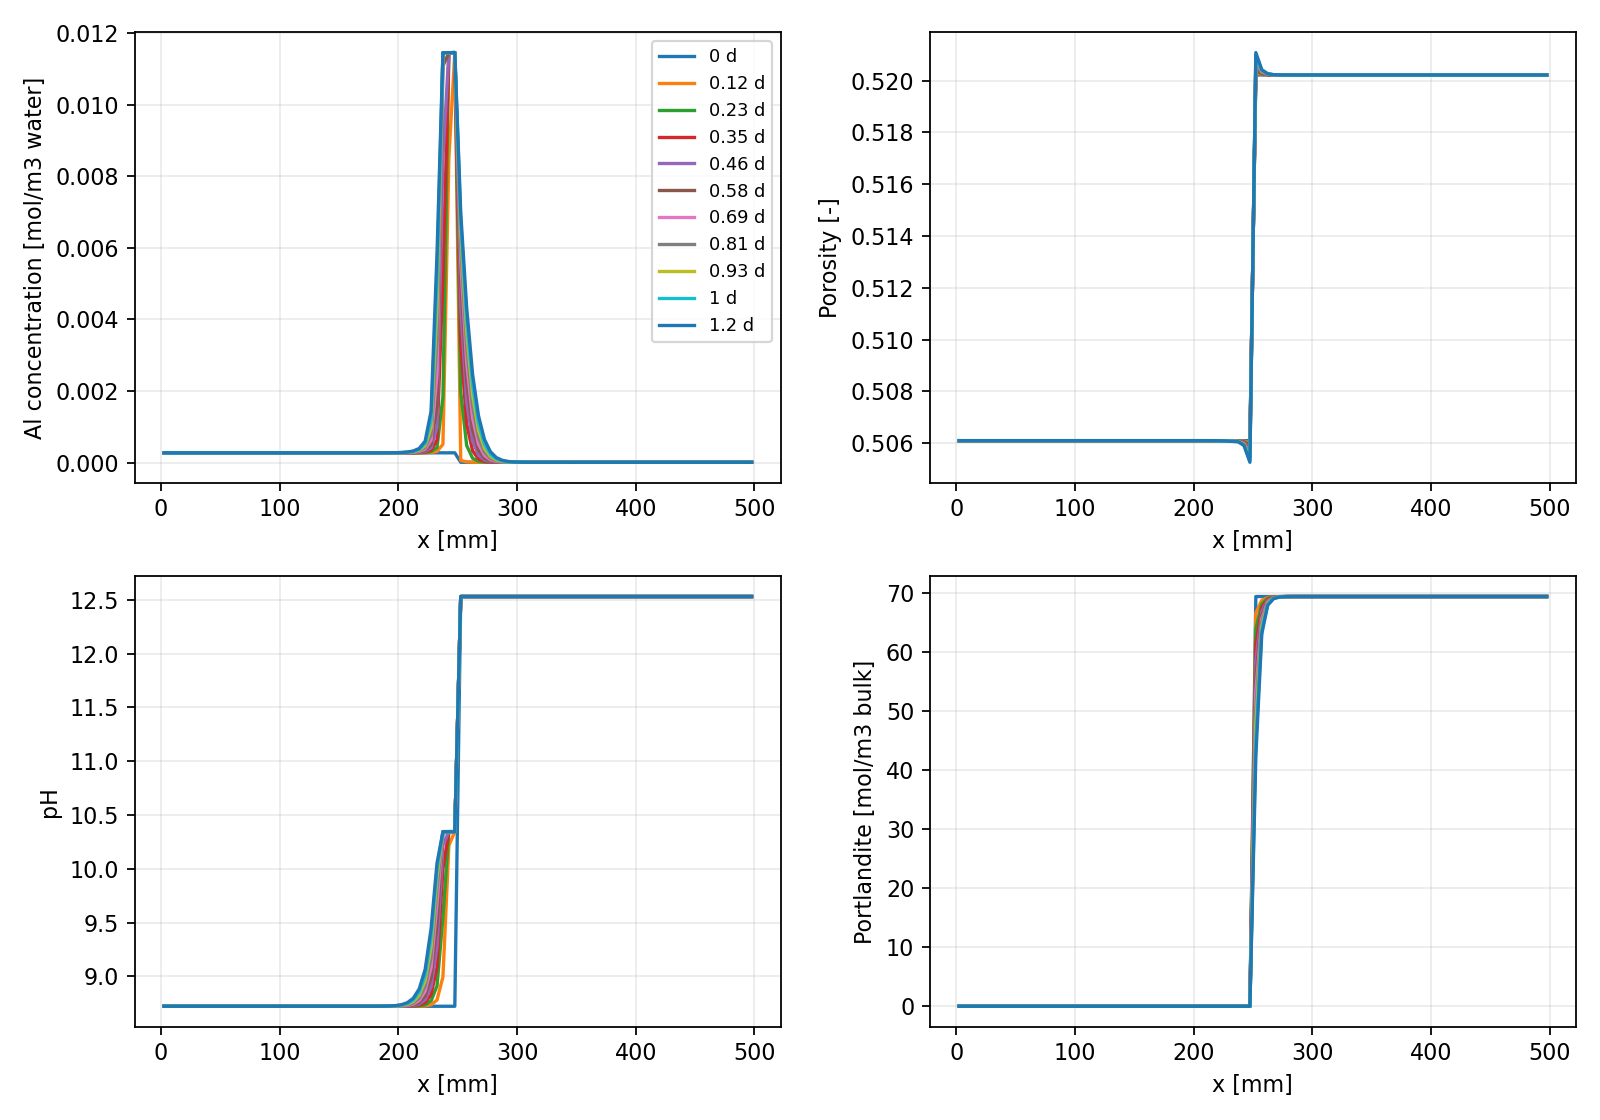

In [3]:
%matplotlib inline
import yaml
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd, matplotlib.pyplot as plt

case = yaml.safe_load(open("case.yaml"))
results = Path(case["output"]["folder"])
summary = (results / "summary.txt").read_text()
print(summary)
if not summary.startswith("COMPLETED"):
    raise RuntimeError("The run did not complete; the reason is printed above (also in results/failure.txt).")
display(Image(filename=str(results / "profiles.png")))
p = pd.read_csv(results / "profiles.csv")

## Comparison with the original, t = 1e5 s

Top: this model in the layout of the original summary figure. Bottom: the original figure
(`reference/cement_clay_original_summary.png`). This model reports **element** concentrations
(Ca, Mg, Na, Cl, Si); the original shows the species Ca²⁺, Mg²⁺, Na⁺, Cl⁻, SiO₂@. Solids are
mol per m³ of bulk in both.

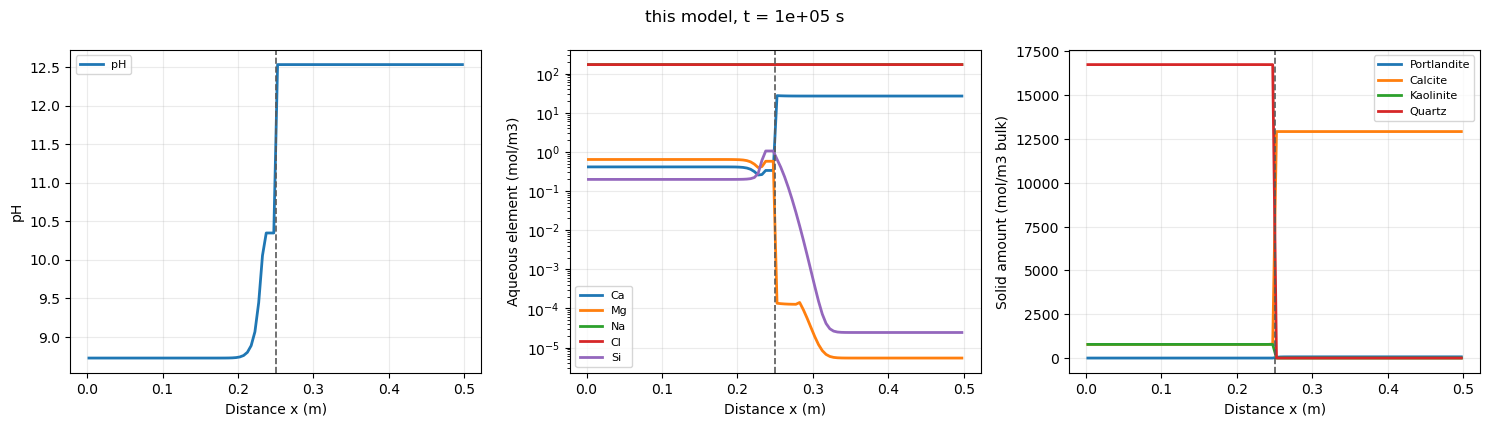

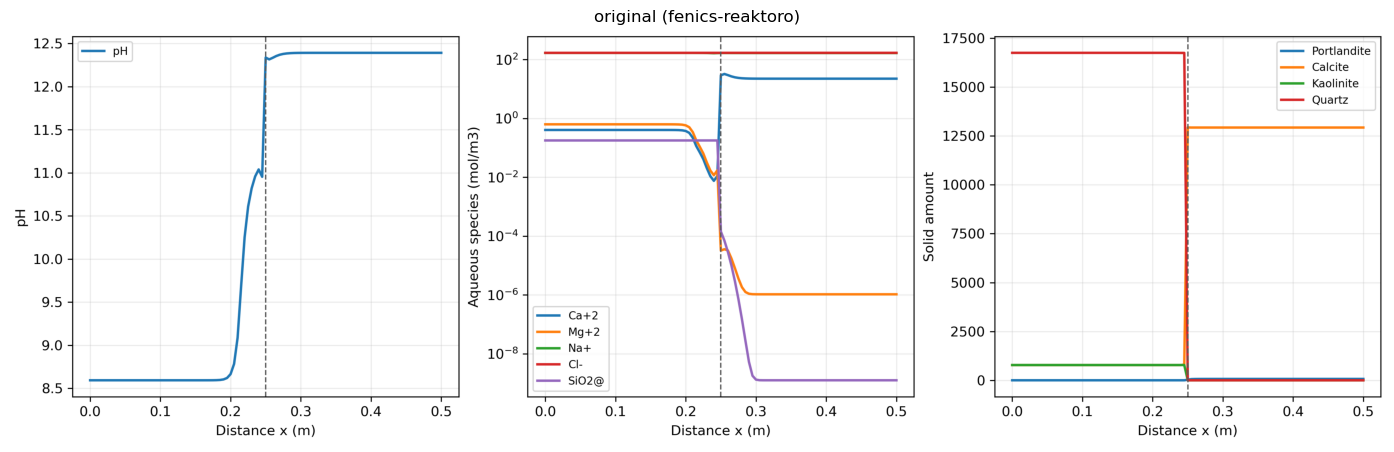

In [4]:
t_end = p["time_s"].max()
s = p[p["time_s"] == t_end].sort_values("x_m")
x = s["x_m"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
axes[0].plot(x, s["pH"], lw=2, label="pH")
for e in ("Ca", "Mg", "Na", "Cl", "Si"):
    axes[1].plot(x, s[f"{e}_c_mol_m3_water"], lw=2, label=e)
axes[1].set_yscale("log")
for m in ("Portlandite", "Calcite", "Kaolinite", "Quartz"):
    axes[2].plot(x, s[f"{m}_mol_m3_bulk"], lw=2, label=m)
for ax, yl in zip(axes, ("pH", "Aqueous element (mol/m3)", "Solid amount (mol/m3 bulk)")):
    ax.axvline(0.25, color="0.35", ls="--", lw=1.2)
    ax.set(xlabel="Distance x (m)", ylabel=yl); ax.grid(alpha=0.25); ax.legend(fontsize=8)
fig.suptitle(f"this model, t = {t_end:.0e} s")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(15, 4.6))
ax.imshow(plt.imread("reference/cement_clay_original_summary.png")); ax.axis("off")
ax.set_title("original (fenics-reaktoro)")
plt.tight_layout(); plt.show()

### Evolution of pH and porosity

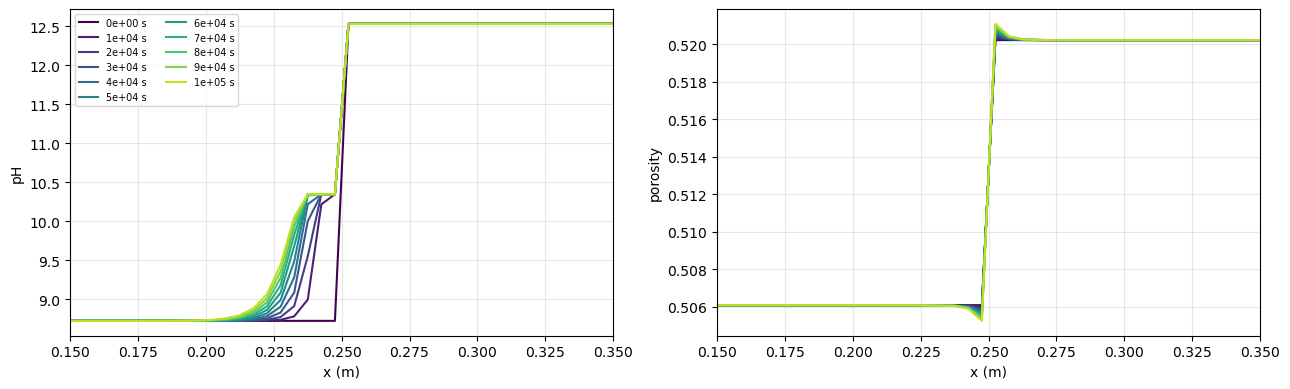

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for k, (t, g) in enumerate(p.groupby("time_s")):
    g = g.sort_values("x_m")
    axes[0].plot(g["x_m"], g["pH"], color=plt.cm.viridis(k / 11), label=f"{t:.0e} s")
    axes[1].plot(g["x_m"], g["phi"], color=plt.cm.viridis(k / 11))
axes[0].set(xlim=(0.15, 0.35), xlabel="x (m)", ylabel="pH"); axes[1].set(xlim=(0.15, 0.35), xlabel="x (m)", ylabel="porosity")
axes[0].legend(fontsize=7, ncol=2)
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Differences to the original

| | Original | This model |
|---|---|---|
| Transport unknowns | 37 aqueous species, each its own $D_i$ | 9 elements, one $D$ = 1e-9 m²/s |
| Discretisation | CG1, chemistry at nodes | DG0 finite volume, chemistry per cell |
| Chemistry | Reaktoro with the GEMS files | GEMS (xgems), cold start + scaled retries |

The chemistry and geometry are the same; expect a narrower pH transition into the clay
because OH⁻ diffuses with 1e-9 instead of 5.3e-9 m²/s.